In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier



In [8]:
df=pd.read_csv('C:\\Users\\Sayed Al Rafi\\Documents\\Data Desktop\\Data_Analysis\\ML project\\Fetal Health Classifier(PJ 4)\\data\\raw\\fetal_health.csv')

In [11]:
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [16]:
df['fetal_health'].value_counts()

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

In [17]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [18]:
df.describe(include='all')

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


## EDA

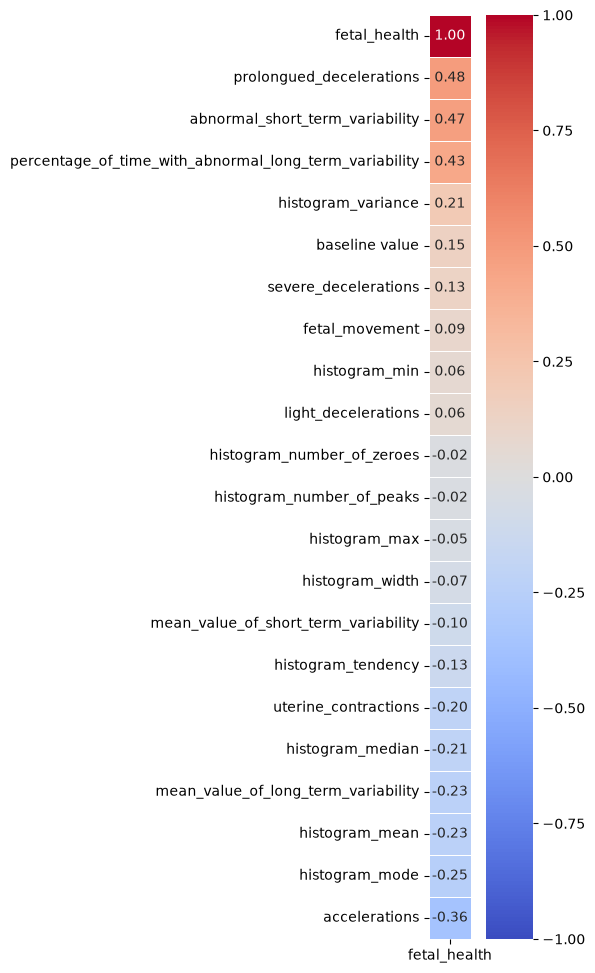

In [26]:
corr_matrix = df.corr()
fatal_health_corr = corr_matrix[['fetal_health']].sort_values(by='fetal_health', ascending=False)

plt.figure(figsize=(4, 12))
sns.heatmap(fatal_health_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, cbar=True, square=True, linewidths=0.5)
plt.show()

In [29]:
from IPython.display import display
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

numeric_df = df.select_dtypes(include=[np.number]).copy()
feature_df = numeric_df.drop(columns=['fetal_health'], errors='ignore')

# 1) VIF calculation

def calculate_vif(df):
    vif_rows = []
    for col in df.columns:
        y = df[col]
        X = df.drop(columns=[col])
        if X.shape[1] == 0:
            continue
        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)
        vif = float('inf') if r2 >= 1 else 1 / (1 - r2)
        vif_rows.append((col, vif))
    return pd.DataFrame(vif_rows, columns=['feature', 'vif']).sort_values('vif', ascending=False)

vif_df = calculate_vif(feature_df)
print('\nVariance Inflation Factor (VIF) for each feature:')
display(vif_df.style.format({'vif': '{:.2f}'}))


Variance Inflation Factor (VIF) for each feature:


,feature,vif
11,histogram_width,inf
12,histogram_min,inf
13,histogram_max,inf
18,histogram_median,26.84
17,histogram_mean,20.10
16,histogram_mode,8.85
0,baseline value,6.71
4,light_decelerations,3.44
8,mean_value_of_short_term_variability,2.96
20,histogram_tendency,2.88


Clearly we can see that there are so many mulicoliniarity.Because we are using tree based model we dont need to handle the multicoliniarity issue.

C:\Users\Sayed Al Rafi\AppData\Local\Temp\ipykernel_19120\52009422.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fetal_health', data=df, palette='viridis')


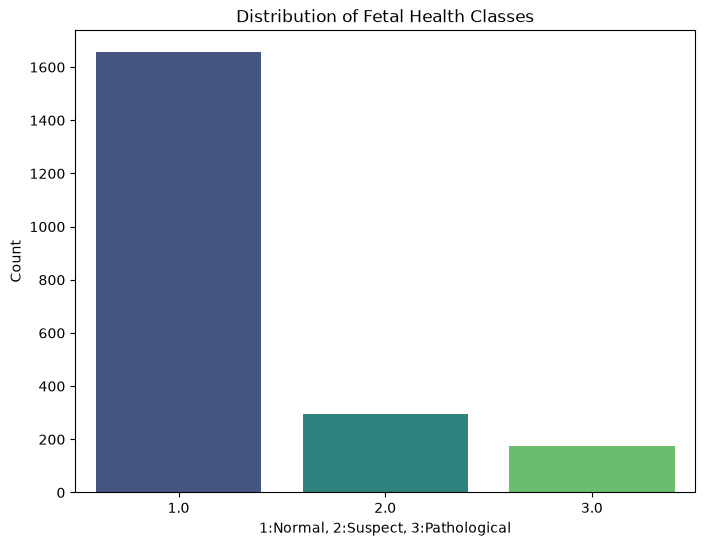

In [30]:
# To check the Class Imbalance in the target variable, we can visualize the distribution of the 'fetal_health' classes using a bar plot.
plt.figure(figsize=(8, 6))
sns.countplot(x='fetal_health', data=df, palette='viridis')
plt.title('Distribution of Fetal Health Classes')
plt.xlabel('1:Normal, 2:Suspect, 3:Pathological')
plt.ylabel('Count')
plt.show()

We can see that its highly Imbalanced

## Model Training

In [31]:
x=df.drop('fetal_health', axis=1)
y=df['fetal_health']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Randomforest Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
Treshold = 0.3

rf=RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        class_weight='balanced',
        random_state=42
    )
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.98      0.95      0.96       332
         2.0       0.74      0.86      0.80        59
         3.0       0.86      0.91      0.89        35

    accuracy                           0.93       426
   macro avg       0.86      0.91      0.88       426
weighted avg       0.94      0.93      0.93       426



In [47]:
rf = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

# Probabilities for classes 1, 2, and 3
probs = rf.predict_proba(x_test)

# Select the class with the highest probability
y_pred = rf.classes_[np.argmax(probs, axis=1)]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.98      0.95      0.96       332
         2.0       0.74      0.85      0.79        59
         3.0       0.86      0.91      0.89        35

    accuracy                           0.93       426
   macro avg       0.86      0.90      0.88       426
weighted avg       0.94      0.93      0.93       426



Decission Tree

In [49]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
classifier.fit(x_train, y_train)
classifier_predictions = classifier.predict(x_test)
print(classification_report(y_test, classifier_predictions))

              precision    recall  f1-score   support

         1.0       0.93      0.98      0.95       332
         2.0       0.88      0.61      0.72        59
         3.0       0.82      0.80      0.81        35

    accuracy                           0.91       426
   macro avg       0.88      0.80      0.83       426
weighted avg       0.91      0.91      0.91       426



LGBM 

In [53]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Create the LightGBM model
lgbm = LGBMClassifier(
    objective="multiclass",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    verbosity=-1
)

# Train the model
lgbm.fit(x_train, y_train)

# Predict classes directly
y_pred_lgbm = lgbm.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))

# Compare training and testing accuracy
print("\nTraining accuracy:", lgbm.score(x_train, y_train))
print("Testing accuracy:", lgbm.score(x_test, y_test))

Accuracy: 0.9483568075117371

Classification Report:
              precision    recall  f1-score   support

         1.0       0.97      0.98      0.97       332
         2.0       0.87      0.80      0.83        59
         3.0       0.87      0.94      0.90        35

    accuracy                           0.95       426
   macro avg       0.90      0.91      0.90       426
weighted avg       0.95      0.95      0.95       426


Confusion Matrix:
[[324   6   2]
 [  9  47   3]
 [  1   1  33]]

Training accuracy: 0.9994117647058823
Testing accuracy: 0.9483568075117371


XGBoost

In [56]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Convert target labels: 1, 2, 3 → 0, 1, 2
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Give more importance to minority classes
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

# Create the XGBoost model
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

# Train the model
xgb.fit(
    x_train,
    y_train_encoded,
    sample_weight=sample_weights
)

# Predict classes directly
y_pred_encoded = xgb.predict(x_test)

# Convert predictions back: 0, 1, 2 → 1, 2, 3
y_pred_xgb = label_encoder.inverse_transform(
    y_pred_encoded.astype(int)
)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nTraining accuracy:", xgb.score(x_train, y_train_encoded))
print("Testing accuracy:", xgb.score(x_test, y_test_encoded))

Accuracy: 0.9389671361502347

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.97      0.97       332
         2.0       0.81      0.78      0.79        59
         3.0       0.92      0.94      0.93        35

    accuracy                           0.94       426
   macro avg       0.90      0.90      0.90       426
weighted avg       0.94      0.94      0.94       426


Confusion Matrix:
[[321  10   1]
 [ 11  46   2]
 [  1   1  33]]

Training accuracy: 0.9970588235294118
Testing accuracy: 0.9389671361502347


Fine Tuning LGBM

In [58]:
import optuna
import mlflow
import mlflow.sklearn
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


# Store MLflow experiments locally
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Fetal-Health-LightGBM-Optuna")

# Reproducible cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

2026/07/21 01:50:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 01:50:05 INFO mlflow.store.db.utils: Updating database tables
2026/07/21 01:50:08 INFO mlflow.tracking.fluent: Experiment with name 'Fetal-Health-LightGBM-Optuna' does not exist. Creating a new experiment.


In [59]:
def objective(trial):

    max_depth = trial.suggest_int("max_depth", 3, 12)

    params = {
        "objective": "multiclass",

        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 800
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),

        "max_depth": max_depth,

        "num_leaves": trial.suggest_int(
            "num_leaves",
            7,
            min(127, 2 ** max_depth)
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 5, 60
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        # Required for subsample to take effect
        "subsample_freq": 1,

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain", 0.0, 1.0
        ),

        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "recall_macro": "recall_macro"
    }

    cv_results = cross_validate(
        model,
        x_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )

    mean_accuracy = cv_results["test_accuracy"].mean()
    mean_balanced_accuracy = (
        cv_results["test_balanced_accuracy"].mean()
    )
    mean_f1_macro = cv_results["test_f1_macro"].mean()
    mean_recall_macro = cv_results["test_recall_macro"].mean()

    with mlflow.start_run(
        run_name=f"trial_{trial.number}",
        nested=True
    ):
        mlflow.log_params(params)

        mlflow.log_metrics({
            "cv_accuracy": mean_accuracy,
            "cv_balanced_accuracy": mean_balanced_accuracy,
            "cv_f1_macro": mean_f1_macro,
            "cv_recall_macro": mean_recall_macro
        })

    # Optuna will maximize this metric
    return mean_f1_macro

In [60]:
with mlflow.start_run(run_name="LightGBM_Optuna_Study") as parent_run:

    study = optuna.create_study(
        study_name="lightgbm_fetal_health",
        direction="maximize",

        # Saves the Optuna study locally
        storage="sqlite:///optuna_lgbm.db",

        # Continue the existing study if it already exists
        load_if_exists=True,

        sampler=optuna.samplers.TPESampler(
            seed=42
        )
    )

    study.optimize(
        objective,
        n_trials=30,
        show_progress_bar=True
    )

    print("Best macro F1-score:", study.best_value)
    print("\nBest parameters:")

    for parameter, value in study.best_params.items():
        print(f"{parameter}: {value}")

    mlflow.log_metric(
        "best_cv_f1_macro",
        study.best_value
    )

    mlflow.log_params({
        f"best_{key}": value
        for key, value in study.best_params.items()
    })

[I 2026-07-21 01:50:30,744] A new study created in RDB with name: lightgbm_fetal_health


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-21 01:50:35,834] Trial 0 finished with value: 0.8977235138660189 and parameters: {'max_depth': 6, 'n_estimators': 766, 'learning_rate': 0.07441632389160634, 'num_leaves': 41, 'min_child_samples': 13, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 0.8977235138660189.
[I 2026-07-21 01:50:40,514] Trial 1 finished with value: 0.9187062463626594 and parameters: {'max_depth': 3, 'n_estimators': 779, 'learning_rate': 0.10779361932748845, 'num_leaves': 7, 'min_child_samples': 15, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.7216968971838151, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'min_split_gain': 0.2912291401980419}. Best is trial 1 with value: 0.9187062463626594.
[I 2026-07-21 01:50:44,415] Trial 2 finished with value: 0.8950746096207526 and parameters: {'max_depth': 9, 'n_estimator

In [61]:
trials_df = study.trials_dataframe()

display(
    trials_df[
        [
            "number",
            "value",
            "state",
            "datetime_start",
            "duration"
        ]
    ]
    .sort_values("value", ascending=False)
    .head(10)
)

,number,value,state,datetime_start,duration
24,24,0.921972,COMPLETE,2026-07-21 01:53:06.365190,0 days 00:00:03.506625
25,25,0.921796,COMPLETE,2026-07-21 01:53:09.917194,0 days 00:00:16.770467
12,12,0.919693,COMPLETE,2026-07-21 01:51:51.367146,0 days 00:00:06.850166
19,19,0.918850,COMPLETE,2026-07-21 01:52:28.986166,0 days 00:00:07.495702
1,1,0.918706,COMPLETE,2026-07-21 01:50:35.863098,0 days 00:00:04.631953
11,11,0.917801,COMPLETE,2026-07-21 01:51:45.752402,0 days 00:00:05.583111
27,27,0.917694,COMPLETE,2026-07-21 01:53:40.983549,0 days 00:00:04.421851
28,28,0.916469,COMPLETE,2026-07-21 01:53:45.437555,0 days 00:00:08.397054
21,21,0.916362,COMPLETE,2026-07-21 01:52:57.480127,0 days 00:00:04.337535
9,9,0.916183,COMPLETE,2026-07-21 01:51:36.688619,0 days 00:00:05.506581


Test accuracy: 0.9342723004694836
Test balanced accuracy: 0.8805167400838219
Test macro F1-score: 0.8773946360153256
Test macro recall: 0.8805167400838219

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.97      0.97       332
         2.0       0.83      0.73      0.77        59
         3.0       0.85      0.94      0.89        35

    accuracy                           0.93       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426



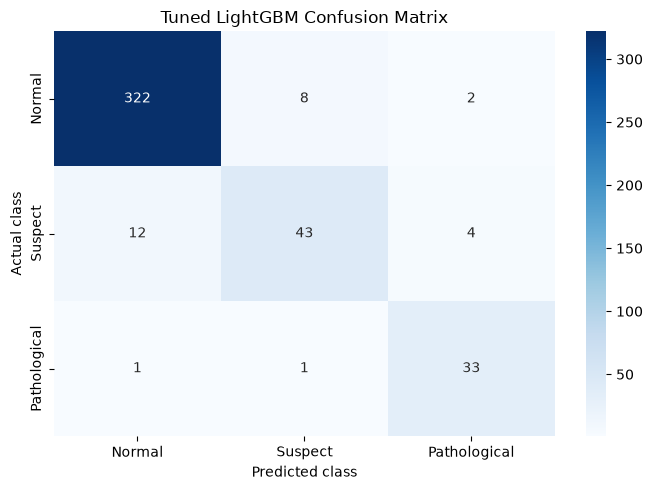

2026/07/21 01:59:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['collections.OrderedDict', 'lightgbm.basic.Booster', 'lightgbm.sklearn.LGBMClassifier'].

In [63]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score
)
best_params = study.best_params.copy()

best_params.update({
    "objective": "multiclass",
    "class_weight": "balanced",
    "subsample_freq": 1,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
})

best_lgbm = LGBMClassifier(**best_params)

with mlflow.start_run(run_name="Best_LightGBM_Model"):

    # Train using the complete training set
    best_lgbm.fit(x_train, y_train)

    # Direct multiclass predictions
    y_pred_best = best_lgbm.predict(x_test)

    test_accuracy = accuracy_score(
        y_test,
        y_pred_best
    )

    test_balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred_best
    )

    test_f1_macro = f1_score(
        y_test,
        y_pred_best,
        average="macro"
    )

    test_recall_macro = recall_score(
        y_test,
        y_pred_best,
        average="macro"
    )

    print("Test accuracy:", test_accuracy)
    print("Test balanced accuracy:", test_balanced_accuracy)
    print("Test macro F1-score:", test_f1_macro)
    print("Test macro recall:", test_recall_macro)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred_best,
            zero_division=0
        )
    )

    # Log parameters and metrics
    mlflow.log_params(best_params)

    mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_balanced_accuracy": test_balanced_accuracy,
        "test_f1_macro": test_f1_macro,
        "test_recall_macro": test_recall_macro
    })

    # Save the classification report
    report = classification_report(
        y_test,
        y_pred_best,
        output_dict=True,
        zero_division=0
    )

    mlflow.log_dict(
        report,
        "classification_report.json"
    )

    # Create and log confusion matrix
    cm = confusion_matrix(
        y_test,
        y_pred_best,
        labels=best_lgbm.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        yticklabels=[
            "Normal",
            "Suspect",
            "Pathological"
        ],
        ax=ax
    )

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title("Tuned LightGBM Confusion Matrix")

    plt.tight_layout()

    mlflow.log_figure(
        fig,
        "confusion_matrix.png"
    )

    plt.show()

    # Save the trained model in MLflow
    mlflow.sklearn.log_model(
        sk_model=best_lgbm,
        artifact_path="lightgbm_model",
        input_example=x_train.head(5)
    )